# Notebook 2: Exploratory Data Analysis
**CRISP-DM Phase 2 — Data Understanding**

Univariate, bivariate, and multivariate analysis of proxy wealth features.
Outlier detection, correlation, and temporal trends across 5 waves.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_cleaner import DataCleaner
from feature_enginner import FeatureEngineer

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)
COLORS = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']

## 2. Load & Clean

In [2]:
df_raw   = pd.read_csv('../data/processed/all_waves_clean.csv')
cleaner  = DataCleaner()
df_clean = cleaner.fit_transform(df_raw)
fe       = FeatureEngineer()
df       = fe.engineer_all(df_clean)

print(f'Dataset: {df.shape[0]:,} households × {df.shape[1]} features')
print(f'Waves: {sorted(df.wave.unique())}')
print(f'Regions: {df.region.nunique()}')

Dataset: 20,278 households × 57 features
Waves: [np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
Regions: 11


## 3. Cleaning Report

In [3]:
cleaner.report()

,step,rows_removed,rows_remaining,nulls_filled,nulls_remaining,values_capped,method,dropped,flags_added
0,drop_missing_target,374.000,20278.000,NaN,NaN,NaN,NaN,NaN,NaN
1,impute,NaN,NaN,147306.000,0.000,NaN,NaN,NaN,NaN
2,cap_outliers,NaN,NaN,NaN,NaN,6835.000,IQR × 3.0 per wave,NaN,NaN
3,drop_zero_variance,NaN,NaN,NaN,NaN,NaN,NaN,"[asset_count, is_tigray_conflict]",NaN
4,add_coverage_flags,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[has_full_housing, has_enterprise_data]"


## 4. Univariate Analysis
### 4a. Continuous Features

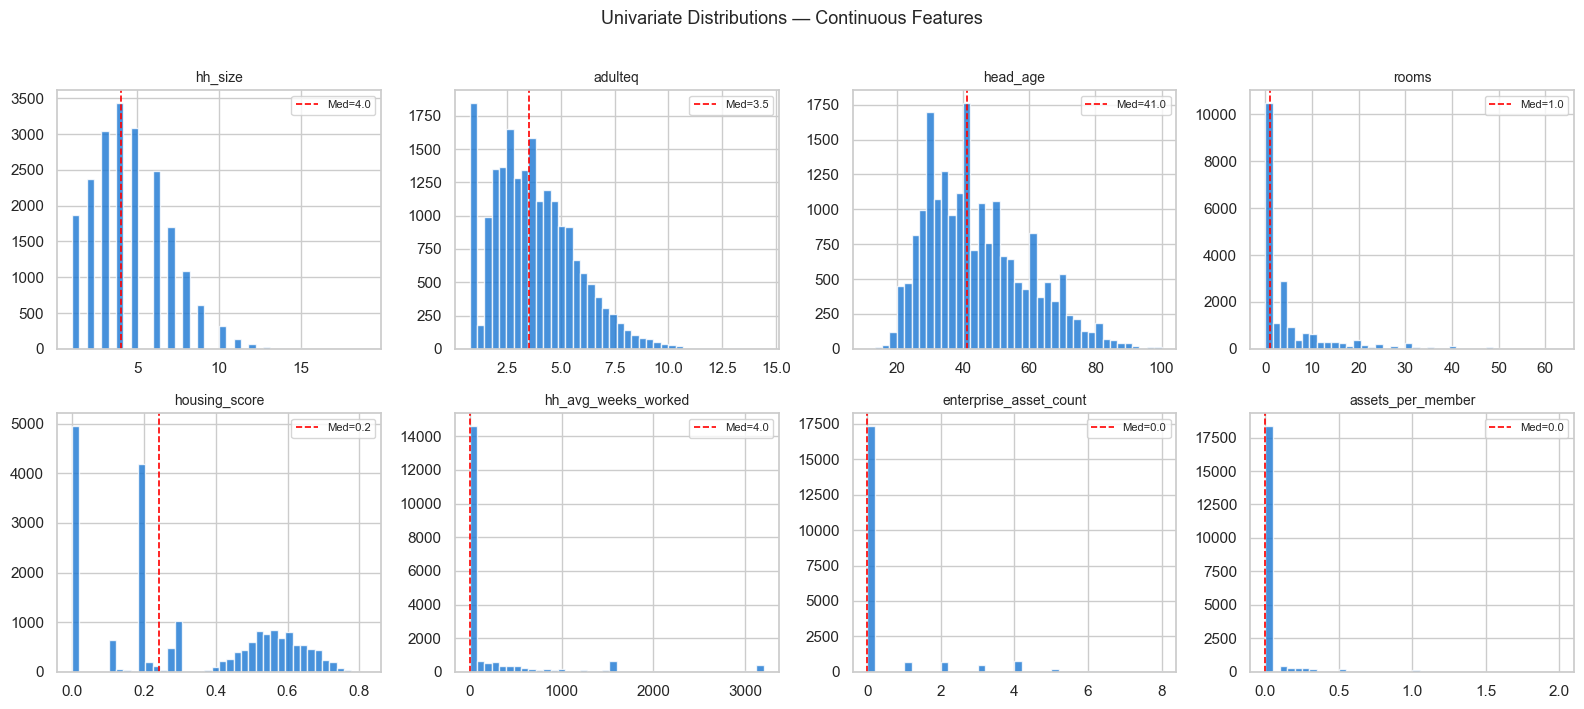

In [4]:
cont_cols = ['hh_size','adulteq','head_age','rooms','housing_score',
             'hh_avg_weeks_worked','enterprise_asset_count','assets_per_member']
cont_cols = [c for c in cont_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, cont_cols):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='#1976D2', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Med={data.median():.1f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Univariate Distributions — Continuous Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/univariate_continuous.png', dpi=120, bbox_inches='tight')
plt.show()

### 4b. Binary Features — Ownership Rates

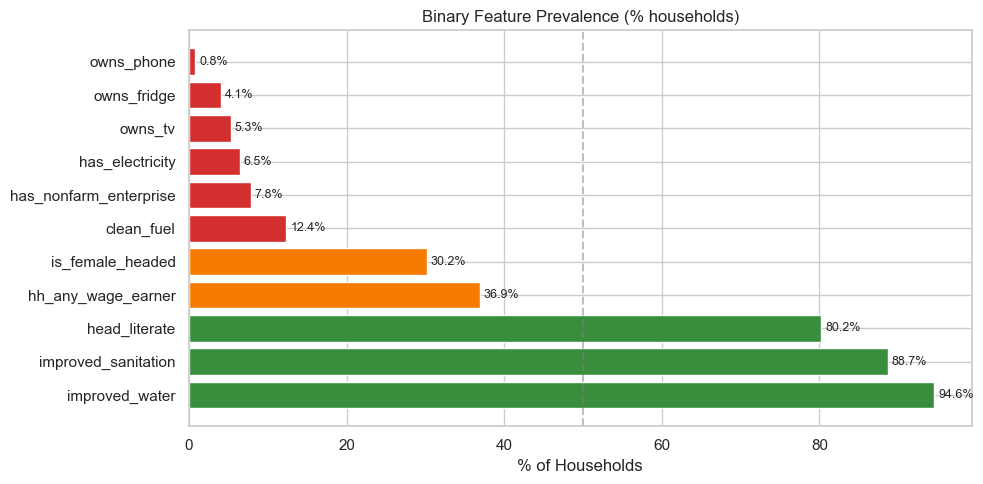

In [5]:
binary_cols = ['owns_phone','owns_tv','owns_fridge','has_electricity',
               'hh_any_wage_earner','has_nonfarm_enterprise','improved_water',
               'improved_sanitation','clean_fuel','is_female_headed','head_literate']
binary_cols = [c for c in binary_cols if c in df.columns]

rates = df[binary_cols].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rates.index, rates.values,
               color=['#388e3c' if v >= 50 else '#f57c00' if v >= 25 else '#d32f2f'
                      for v in rates.values],
               edgecolor='white')
ax.set_xlabel('% of Households')
ax.set_title('Binary Feature Prevalence (% households)')
ax.axvline(50, color='grey', linestyle='--', alpha=0.5)
for bar, v in zip(bars, rates.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/binary_prevalence.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Bivariate Analysis — Features vs Wealth Quintile
### 5a. Continuous features by quintile

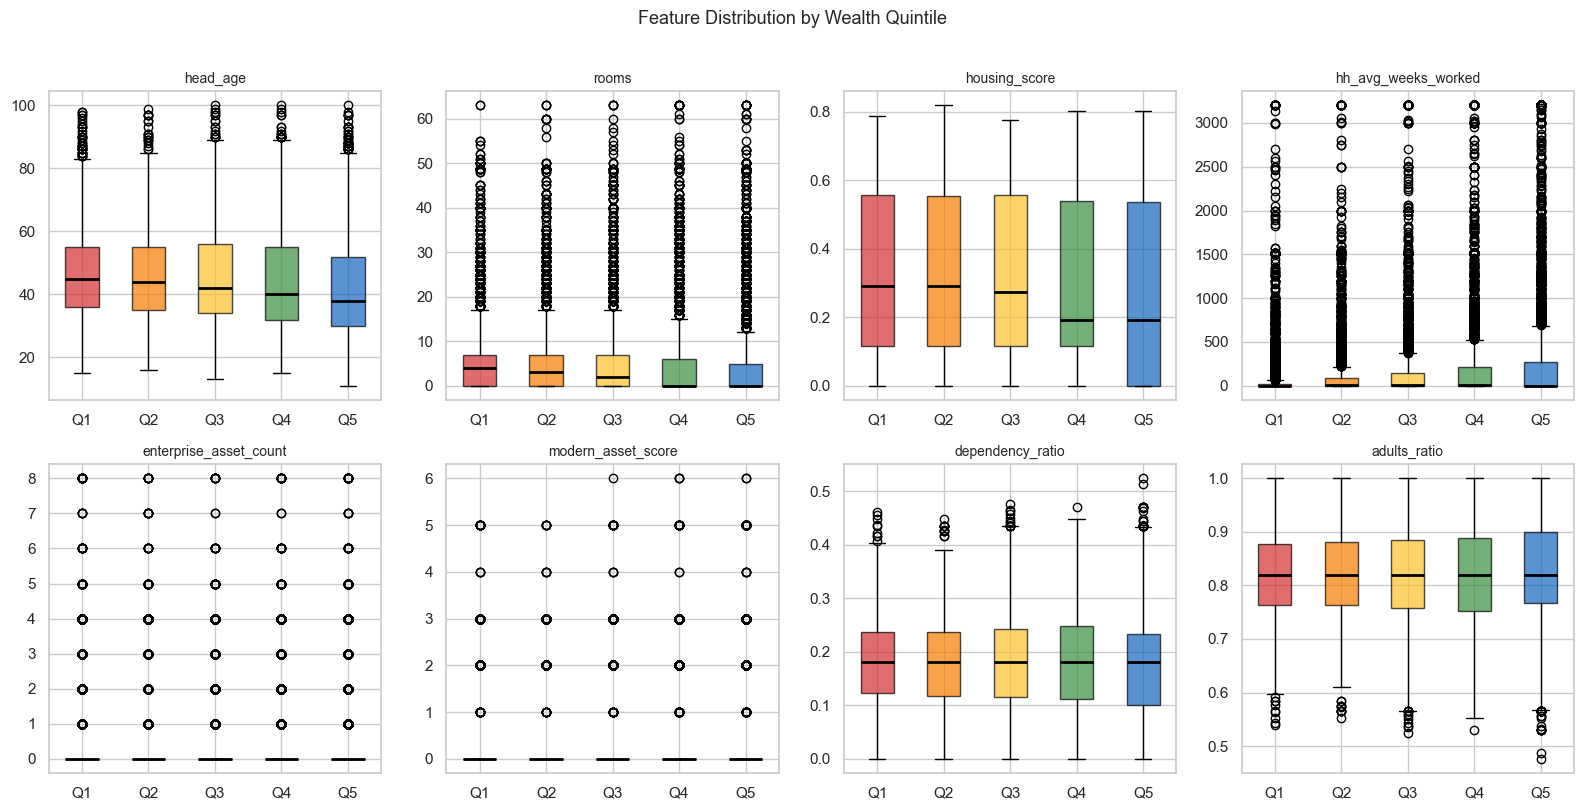

In [6]:
key_cont = ['head_age','rooms','housing_score','hh_avg_weeks_worked',
            'enterprise_asset_count','modern_asset_score','dependency_ratio','adults_ratio']
key_cont = [c for c in key_cont if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, key_cont):
    data = [df.loc[df['cons_quint']==q, col].dropna() for q in range(1,6)]
    bp = ax.boxplot(data, patch_artist=True, medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([f'Q{i}' for i in range(1,6)])
    ax.set_title(col, fontsize=10)
plt.suptitle('Feature Distribution by Wealth Quintile', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/bivariate_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

### 5b. Asset & housing ownership rate by quintile

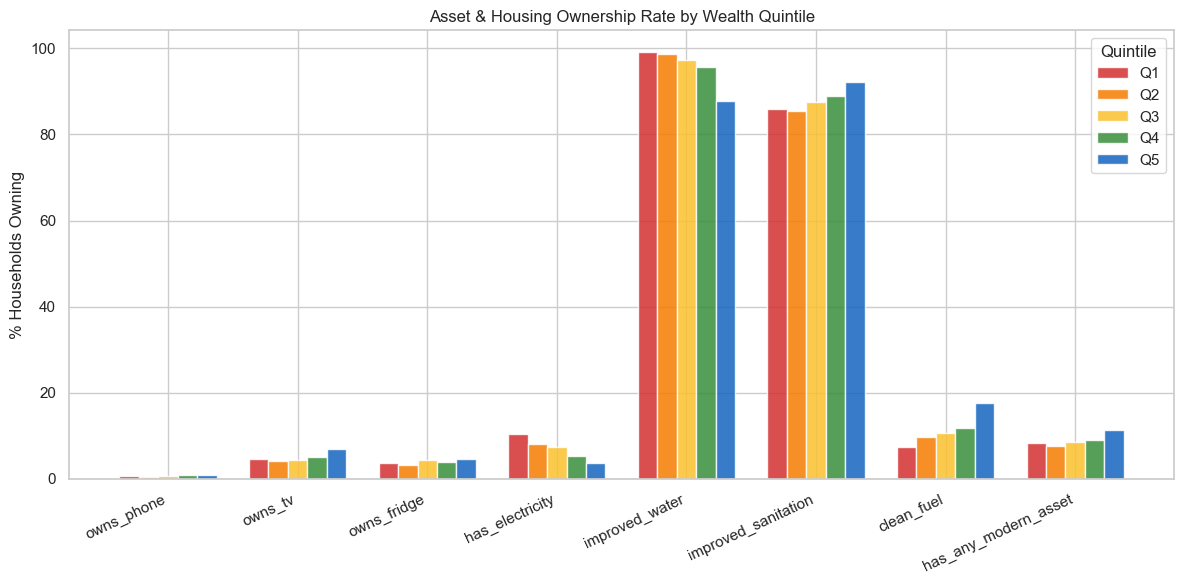

In [7]:
asset_cols = ['owns_phone','owns_tv','owns_fridge','has_electricity',
              'improved_water','improved_sanitation','clean_fuel','has_any_modern_asset']
asset_cols = [c for c in asset_cols if c in df.columns]

rates_by_q = (
    df.groupby('cons_quint')[asset_cols].mean() * 100
).T.rename(columns={q:f'Q{q}' for q in range(1,6)})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(rates_by_q))
width = 0.15
for i, (col, color) in enumerate(zip(rates_by_q.columns, COLORS)):
    ax.bar(x + i*width, rates_by_q[col], width, label=col, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + 2*width)
ax.set_xticklabels(rates_by_q.index, rotation=25, ha='right')
ax.set_ylabel('% Households Owning')
ax.set_title('Asset & Housing Ownership Rate by Wealth Quintile')
ax.legend(title='Quintile')
plt.tight_layout()
plt.savefig('../reports/asset_by_quintile.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Multivariate Analysis
### 6a. Correlation heatmap

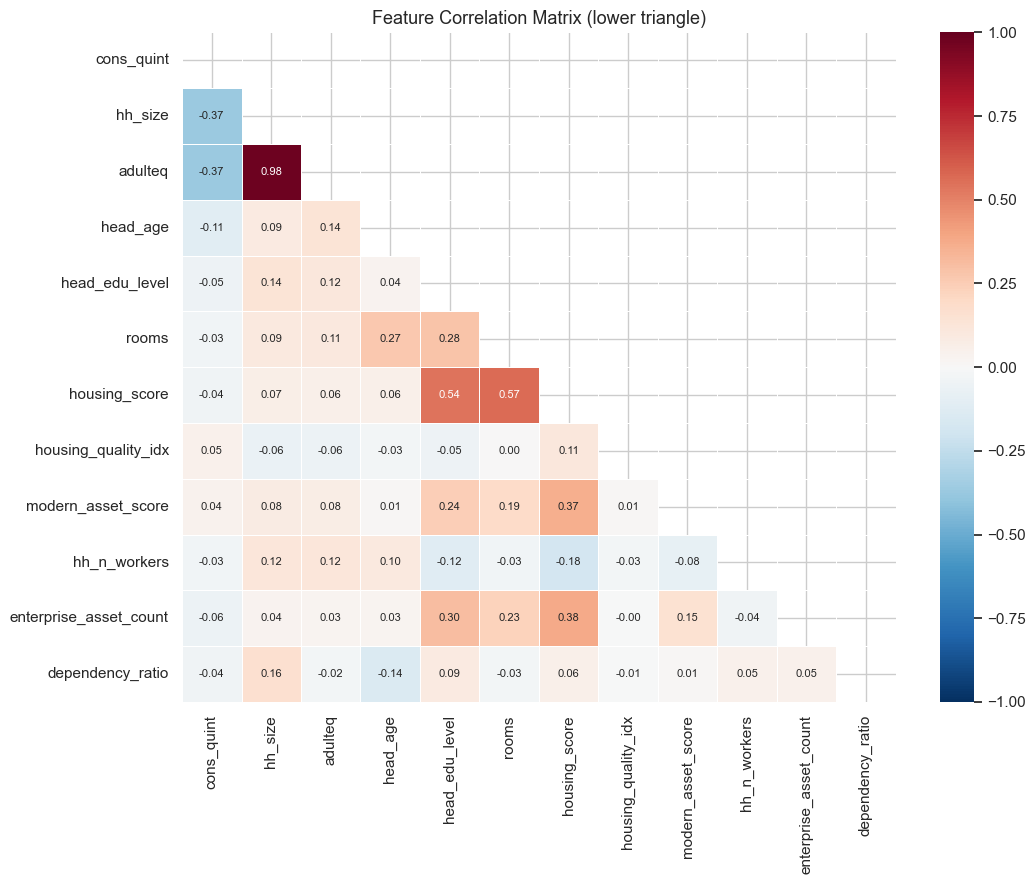

In [8]:
num_cols = ['cons_quint','hh_size','adulteq','head_age','head_edu_level',
            'rooms','housing_score','housing_quality_idx','modern_asset_score',
            'hh_n_workers','enterprise_asset_count','n_shocks','dependency_ratio']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size':8}, linewidths=0.4)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 6b. Region × Settlement wealth heatmap

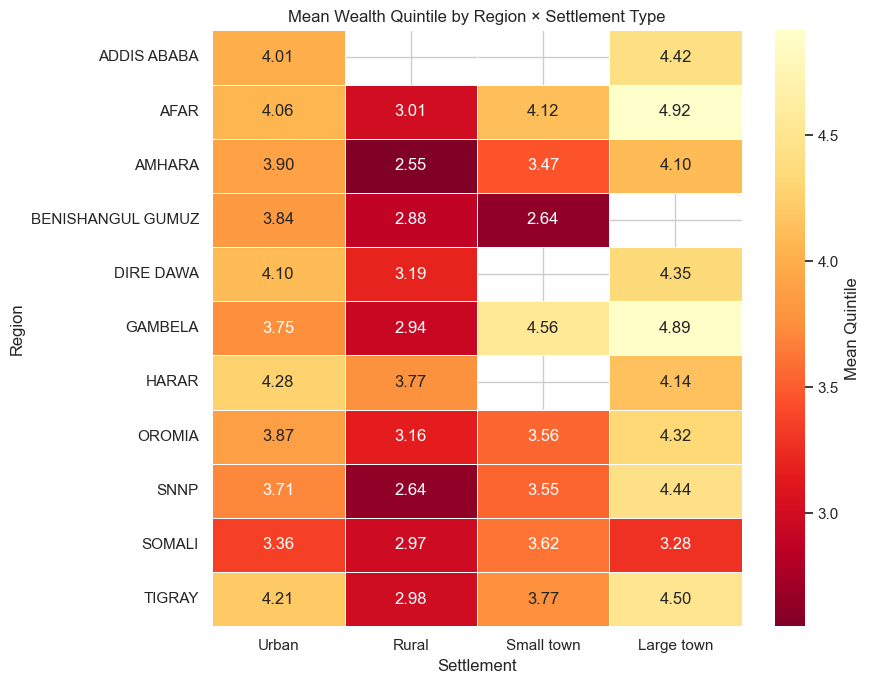

In [9]:
pivot = (
    df.groupby(['region','settlement'], observed=True)['cons_quint']
    .mean().unstack()
    .rename(columns={0:'Urban',1:'Rural',2:'Small town',3:'Large town'})
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd_r',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Mean Quintile'})
ax.set_title('Mean Wealth Quintile by Region × Settlement Type')
ax.set_xlabel('Settlement')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('../reports/region_settlement_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Temporal Trends Across Waves

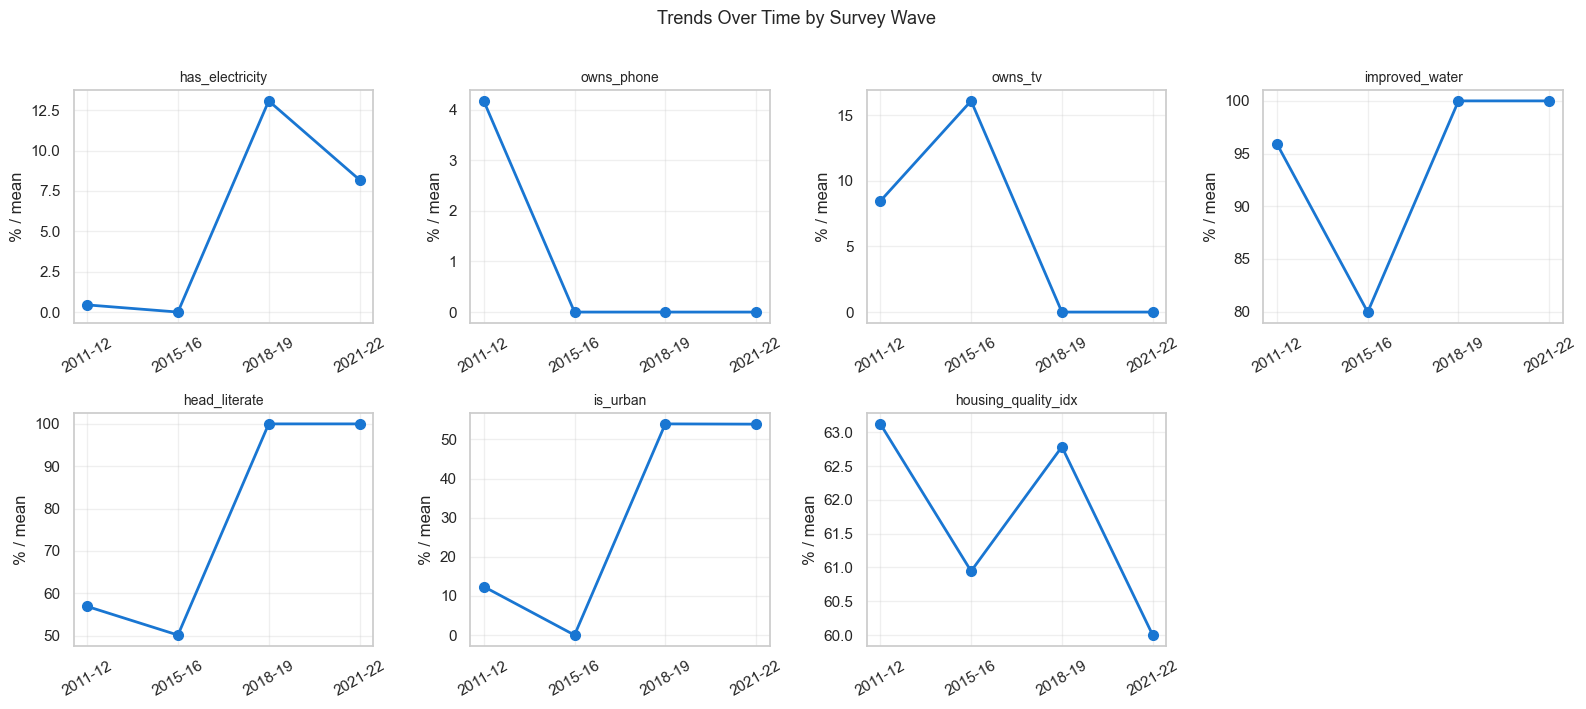

In [10]:
wave_labels = {1:'2011-12',3:'2015-16',4:'2018-19',5:'2021-22'}

trend_cols = ['has_electricity','owns_phone','owns_tv','improved_water',
              'head_literate','is_urban','housing_quality_idx']
trend_cols = [c for c in trend_cols if c in df.columns]

trend = df.groupby('wave')[trend_cols].mean() * 100
trend.index = trend.index.map(lambda w: wave_labels.get(w, str(w)))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, trend_cols):
    ax.plot(trend.index, trend[col], 'o-', linewidth=2, markersize=7, color='#1976D2')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('% / mean')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)
# hide unused
for ax in axes.flat[len(trend_cols):]:
    ax.set_visible(False)
plt.suptitle('Trends Over Time by Survey Wave', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/temporal_trends.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Outlier Detection

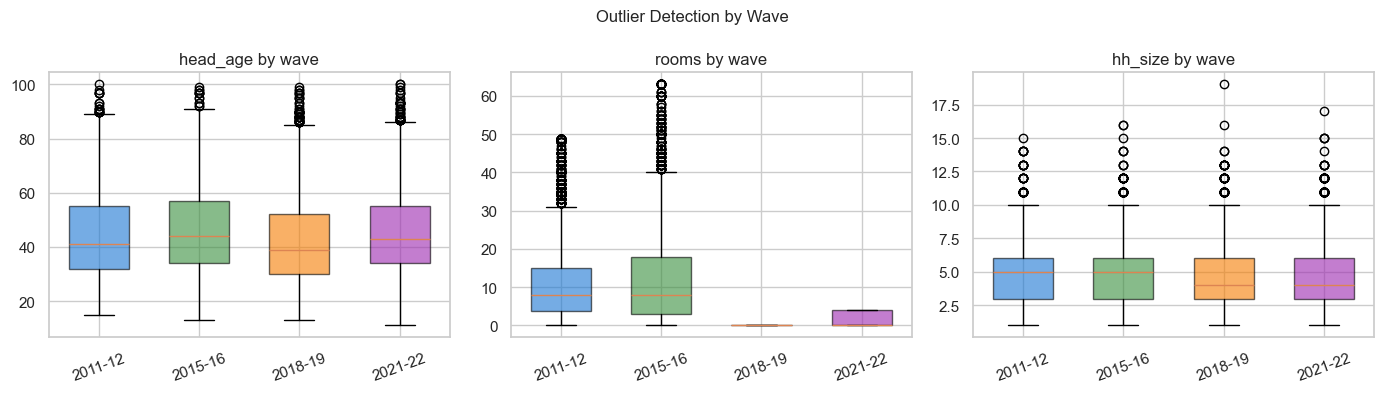

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['head_age','rooms','hh_size']):
    if col not in df.columns:
        continue
    for w, color in zip(sorted(df.wave.unique()), ['#1976D2','#388e3c','#f57c00','#9c27b0']):
        data = df[df['wave']==w][col].dropna()
        ax.boxplot(data, positions=[list(sorted(df.wave.unique())).index(w)],
                   widths=0.6, patch_artist=True,
                   boxprops={'facecolor':color,'alpha':0.6})
    ax.set_xticks(range(4))
    ax.set_xticklabels([wave_labels.get(w,str(w)) for w in sorted(df.wave.unique())],
                       rotation=20)
    ax.set_title(f'{col} by wave')

plt.suptitle('Outlier Detection by Wave', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/outlier_detection.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Shock Analysis

TypeError: no numeric data to plot

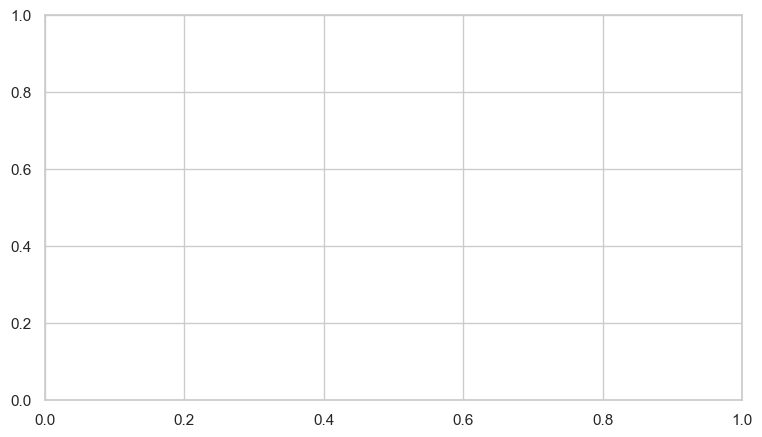

In [13]:
shock_cols = ['experienced_drought','experienced_illness',
              'experienced_death','experienced_crop_loss']
shock_cols = [c for c in shock_cols if c in df.columns]

shock_by_q = df.groupby('cons_quint')[shock_cols].mean() * 100
shock_by_q.index = [f'Q{i}' for i in shock_by_q.index]
shock_by_q.columns = [c.replace('experienced_','') for c in shock_by_q.columns]

fig, ax = plt.subplots(figsize=(9, 5))
shock_by_q.plot(kind='bar', ax=ax, edgecolor='white',color=['#1565c0','#d32f2f','#6a1b9a','#e65100'])
ax.set_title('Shock Exposure Rate by Wealth Quintile')
ax.set_xlabel('Wealth Quintile')
ax.set_ylabel('% Households Affected')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Shock type')
plt.tight_layout()
plt.savefig('../reports/shock_analysis.png', dpi=120, bbox_inches='tight')
plt.show()